In [1]:
!pip install opencv-python matplotlib pandas seaborn torch torchvision scikit-learn albumentations

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 297.8 kB/s eta 0:02:26
   ---------------------------------------- 0.5/44.0 MB 297.8 kB/s eta 0:02:26
   ---------------------------------------- 0.5/44.0 MB 297.8 kB/s eta 0:02:26
   ---------------------------------------- 0.5/44.0 MB 297.8 kB/s eta 0:02:26
   ---------------------------------------- 0.5/44.0 MB 297.8 kB/s eta 0:02:26
   ---------------------------------------- 0


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


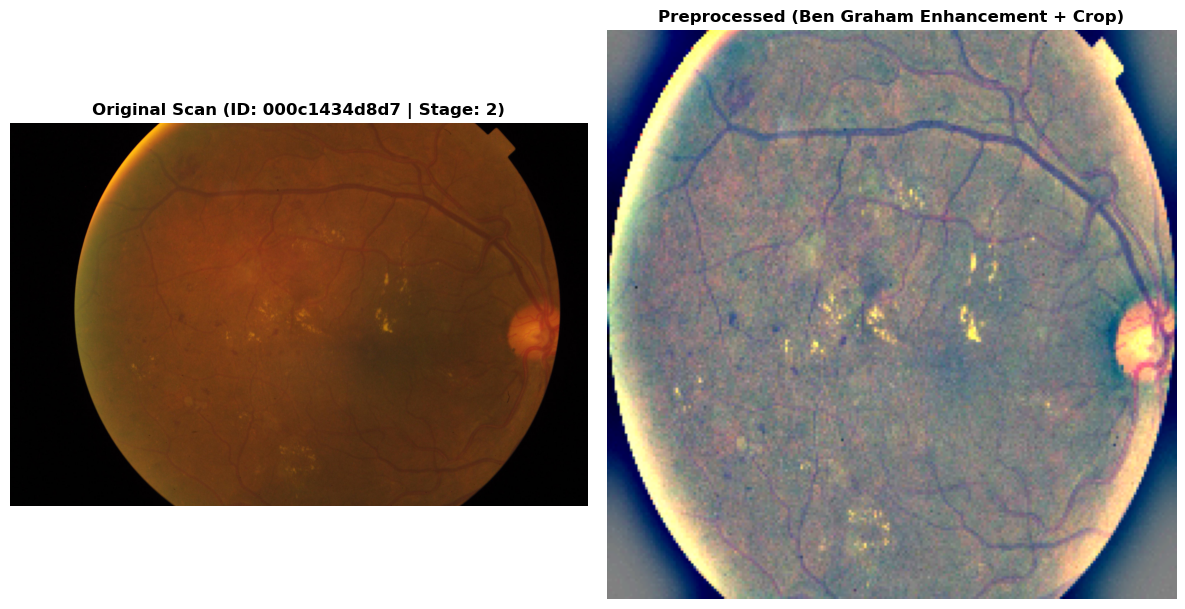

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Updated folder path pointing to subfolder
DATA_DIR = 'aptos2019-blindness-detection'

# Read CSV from subfolder
df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))

def crop_image_from_gray(img, tol=7):
    """Crops uninformative outer dark boundaries around retinal images."""
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol
        if not mask.any():
            return img
        img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
        img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
        img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
        return np.stack([img1, img2, img3], axis=-1)

def preprocess_retina_image(image_path, sigmaX=10, img_size=224):
    """Applies resizing, cropping, and Ben Graham contrast enhancement."""
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = crop_image_from_gray(image)
    image = cv2.resize(image, (img_size, img_size))
    
    # Ben Graham enhancement method
    enhanced = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0, 0), sigmaX), -4, 128)
    return enhanced

# Display sample from aptos2019-blindness-detection/train_images folder
sample_id = df.iloc[0]['id_code']
sample_stage = df.iloc[0]['diagnosis']
sample_img_path = os.path.join(DATA_DIR, 'train_images', f"{sample_id}.png")

orig = cv2.cvtColor(cv2.imread(sample_img_path), cv2.COLOR_BGR2RGB)
prep = preprocess_retina_image(sample_img_path)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(orig)
ax[0].set_title(f"Original Scan (ID: {sample_id} | Stage: {sample_stage})", fontweight='bold')
ax[0].axis('off')

ax[1].imshow(prep)
ax[1].set_title("Preprocessed (Ben Graham Enhancement + Crop)", fontweight='bold')
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [5]:
!pip install torch torchvision scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import sys
!{sys.executable} -m pip install torch torchvision scikit-learn

  Using cached torch-2.14.0-cp313-cp313-win_amd64.whl.metadata (38 kB)
  Using cached torchvision-0.29.0-cp313-cp313-win_amd64.whl.metadata (5.7 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached torch-2.14.0-cp313-cp313-win_amd64.whl (124.1 MB)
Using cached torchvision-0.29.0-cp313-cp313-win_amd64.whl (1.4 MB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 2.3 MB/s eta 0:00:01
   ------------------------ --------------- 1.3/2.1 MB 2.4 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.3 MB/s  0:00:00
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: D:\Python_Data_Science\nibm_env\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class KaggleDRDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = f"{self.df.iloc[idx]['id_code']}.png"
        img_path = os.path.join(self.img_dir, img_name)
        image = preprocess_retina_image(img_path)
        
        if self.transform:
            image = self.transform(image)
            
        label = int(self.df.iloc[idx]['diagnosis'])
        return image, label

# Stratified Split on local Kaggle dataset
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['diagnosis'], random_state=42)

train_dataset = KaggleDRDataset(train_df, os.path.join(DATA_DIR, 'train_images'), transform=train_transform)
val_dataset = KaggleDRDataset(val_df, os.path.join(DATA_DIR, 'train_images'), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Kaggle Train samples: {len(train_df)} | Validation samples: {len(val_df)}")

Kaggle Train samples: 2929 | Validation samples: 733


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights

# Automatically detect GPU or fallback to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_resnet50_model(num_classes=5):
    # Load pre-trained ResNet50 weights
    weights = ResNet50_Weights.DEFAULT
    model = resnet50(weights=weights)
    
    # Freeze initial convolutional layers to preserve learned low-level features
    for param in list(model.parameters())[:-15]:
        param.requires_grad = False
        
    # Replace the fully connected head with custom classifier
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model.to(device)

model = build_resnet50_model(num_classes=5)

# Loss Function & Optimizer Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

print(f"ResNet50 Model initialized successfully on target device: {device}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\ASUS/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:55<00:00, 1.85MB/s]


ResNet50 Model initialized successfully on target device: cpu


In [4]:
import time
#Training phase with 5 epochs
epochs = 5
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Starting ResNet50 Training Loop...\n")

for epoch in range(epochs):
    start_time = time.time()
    
    # ------------------
    # 1. Training Phase
    # ------------------
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    train_loss = running_loss / total
    train_acc = correct / total

    # --------------------
    # 2. Validation Phase
    # --------------------
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            
    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    
    # Adjust learning rate based on validation loss
    scheduler.step(val_loss)
    
    # Record metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    elapsed = time.time() - start_time
    print(f"Epoch [{epoch+1:02d}/{epochs}] ({elapsed:.1f}s) | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

print("\nTraining complete!")

Starting ResNet50 Training Loop...

Epoch [01/5] (1372.1s) | Train Loss: 1.0821, Train Acc: 0.5770 | Val Loss: 0.9101, Val Acc: 0.6780
Epoch [02/5] (1136.9s) | Train Loss: 0.7907, Train Acc: 0.7153 | Val Loss: 0.7510, Val Acc: 0.7326
Epoch [03/5] (1177.7s) | Train Loss: 0.6903, Train Acc: 0.7426 | Val Loss: 0.6953, Val Acc: 0.7517
Epoch [04/5] (1212.1s) | Train Loss: 0.6649, Train Acc: 0.7467 | Val Loss: 0.6714, Val Acc: 0.7531
Epoch [05/5] (1122.3s) | Train Loss: 0.6235, Train Acc: 0.7620 | Val Loss: 0.6547, Val Acc: 0.7585

Training complete!


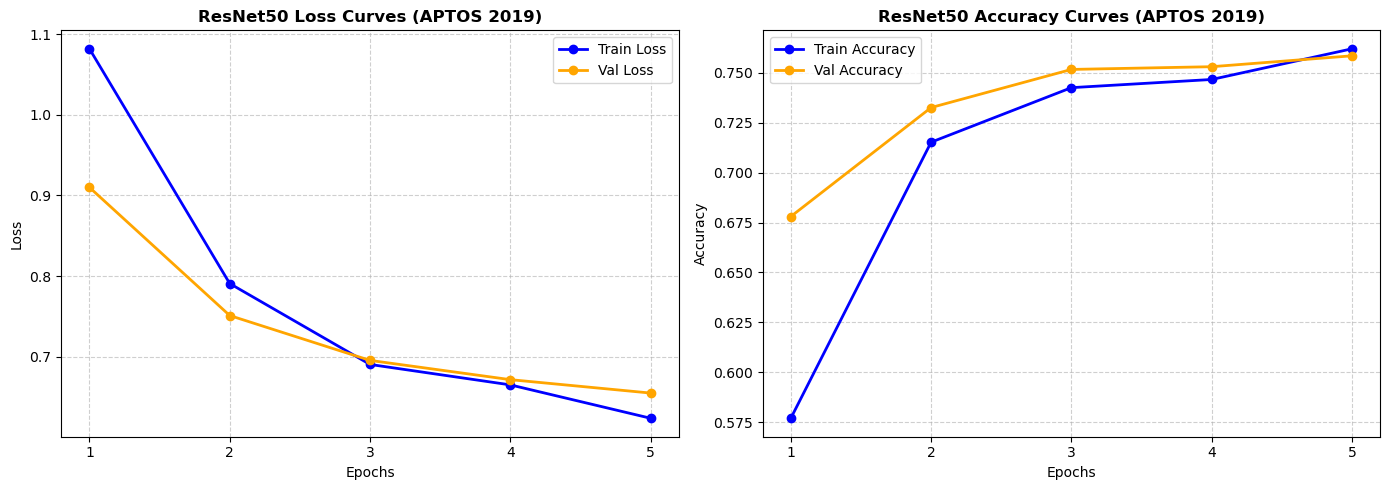

Evaluating model predictions across validation set...

             DETAILED CLASSIFICATION REPORT                  

                   precision    recall  f1-score   support

        No DR (0)       0.92      0.97      0.94       361
         Mild (1)       0.58      0.28      0.38        74
     Moderate (2)       0.58      0.91      0.71       200
       Severe (3)       1.00      0.03      0.05        39
Proliferative (4)       0.50      0.02      0.03        59

         accuracy                           0.76       733
        macro avg       0.72      0.44      0.42       733
     weighted avg       0.76      0.76      0.70       733



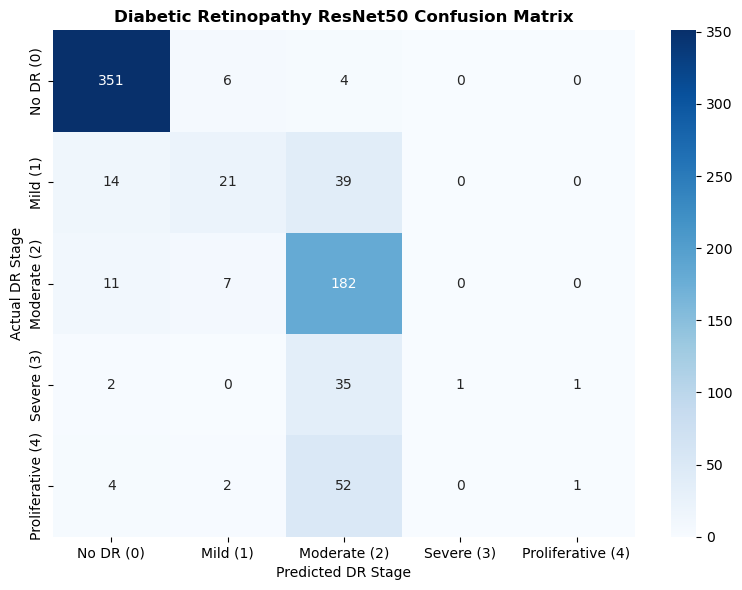

In [5]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ------------------------------------------------------------
# 1. Plot Training & Validation Loss and Accuracy Curves
# ------------------------------------------------------------
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', marker='o', linewidth=2)
plt.plot(epochs_range, history['val_loss'], label='Val Loss', color='orange', marker='o', linewidth=2)
plt.title('ResNet50 Loss Curves (APTOS 2019)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Accuracy', color='blue', marker='o', linewidth=2)
plt.plot(epochs_range, history['val_acc'], label='Val Accuracy', color='orange', marker='o', linewidth=2)
plt.title('ResNet50 Accuracy Curves (APTOS 2019)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. Compute Confusion Matrix & Classification Metrics
# ------------------------------------------------------------
y_true, y_pred = [], []
model.eval()

print("Evaluating model predictions across validation set...")
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

classes = ['No DR (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Proliferative (4)']

print("\n=============================================================")
print("             DETAILED CLASSIFICATION REPORT                  ")
print("=============================================================\n")
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

# ------------------------------------------------------------
# 3. Plot Heatmap Confusion Matrix
# ------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.ylabel('Actual DR Stage')
plt.xlabel('Predicted DR Stage')
plt.title('Diabetic Retinopathy ResNet50 Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
import torch

# Save model parameters locally
model_path = "resnet50_aptos2019.pth"
torch.save(model.state_dict(), model_path)

print(f"Model successfully saved to '{model_path}'!")

Model successfully saved to 'resnet50_aptos2019.pth'!


Model successfully loaded for testing!


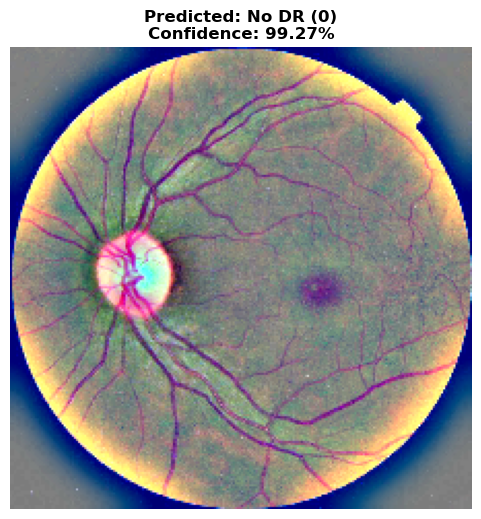

--- Class Probabilities ---
No DR (0): 99.27%
Mild DR (1): 0.40%
Moderate DR (2): 0.29%
Severe DR (3): 0.01%
Proliferative DR (4): 0.03%


In [8]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.models import resnet50

# ------------------------------------------------------------
# 1. Setup Device & Load Saved Model Weights
# ------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def load_trained_model(weights_path="resnet50_aptos2019.pth", num_classes=5):
    model = resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval()
    return model

model = load_trained_model()
print("Model successfully loaded for testing!")

# ------------------------------------------------------------
# 2. Inference Function for a Single Image
# ------------------------------------------------------------
classes = ['No DR (0)', 'Mild DR (1)', 'Moderate DR (2)', 'Severe DR (3)', 'Proliferative DR (4)']

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_retina_stage(image_path):
    # Preprocess using Ben Graham's method
    prep_img = preprocess_retina_image(image_path)
    
    # Transform for PyTorch model tensor input
    tensor_img = test_transform(prep_img).unsqueeze(0).to(device)
    
    # Inference
    with torch.no_grad():
        outputs = model(tensor_img)
        probabilities = torch.softmax(outputs, dim=1)[0]
        confidence, predicted_class = torch.max(probabilities, 0)
        
    return prep_img, predicted_class.item(), confidence.item(), probabilities.cpu().numpy()

# ------------------------------------------------------------
# 3. Test on a Sample Image from the Dataset
# ------------------------------------------------------------
# Select any sample from train_images or test_images
DATA_DIR = 'aptos2019-blindness-detection'
sample_img_id = df.iloc[10]['id_code']  # Try changing index (e.g., 0, 5, 10)
sample_img_path = os.path.join(DATA_DIR, 'train_images', f"{sample_img_id}.png")

prep_img, pred_class, confidence, probs = predict_retina_stage(sample_img_path)

# Display Prediction Output
plt.figure(figsize=(6, 6))
plt.imshow(prep_img)
plt.title(f"Predicted: {classes[pred_class]}\nConfidence: {confidence*100:.2f}%", fontweight='bold')
plt.axis('off')
plt.show()

# Print Class Probabilities
print("--- Class Probabilities ---")
for i, stage_name in enumerate(classes):
    print(f"{stage_name}: {probs[i]*100:.2f}%")

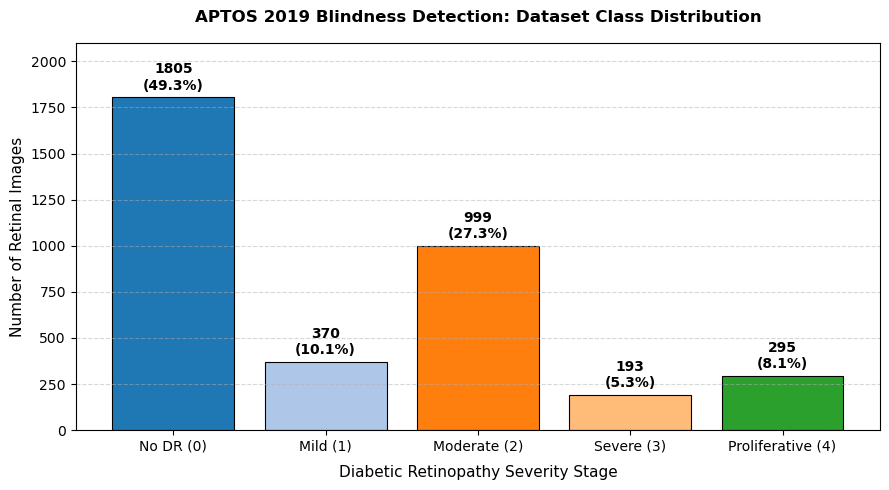

Figure successfully saved as 'aptos_class_distribution.png'!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset class counts
stages = ['No DR (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Proliferative (4)']
counts = [1805, 370, 999, 193, 295]
colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c']

plt.figure(figsize=(9, 5))
bars = plt.bar(stages, counts, color=colors, edgecolor='black', linewidth=0.8)

# Add exact counts and percentages above each bar
total = sum(counts)
for bar in bars:
    yval = bar.get_height()
    pct = (yval / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 25, 
             f'{yval}\n({pct:.1f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('APTOS 2019 Blindness Detection: Dataset Class Distribution', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Diabetic Retinopathy Severity Stage', fontsize=11, labelpad=8)
plt.ylabel('Number of Retinal Images', fontsize=11)
plt.ylim(0, 2100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('aptos_class_distribution.png', dpi=300)
plt.show()

print("Figure successfully saved as 'aptos_class_distribution.png'!")

In [5]:
import gradio as gr
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import cv2
import numpy as np

# ---------------------------------------------------------
# 1. Individual Pipeline Functions (Extracting Intermediate Steps)
# ---------------------------------------------------------
def crop_image_from_gray(img, tol=7):
    """Crops uninformative dark borders around retinal images."""
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol
        if not mask.any():
            return img
        img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
        img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
        img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
        return np.stack([img1, img2, img3], axis=-1)

def process_pipeline_stages(pil_img, sigmaX=10, img_size=224):
    """Executes step-by-step preprocessing and returns each intermediate stage image."""
    raw_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    
    # Step 1: Grayscale Threshold Crop
    cropped_bgr = crop_image_from_gray(raw_bgr)
    cropped_rgb = cv2.cvtColor(cropped_bgr, cv2.COLOR_BGR2RGB)
    
    # Step 2: Spatial Resizing (224 x 224)
    resized_bgr = cv2.resize(cropped_bgr, (img_size, img_size))
    resized_rgb = cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2RGB)
    
    # Step 3: Ben Graham Contrast & Edge Enhancement
    enhanced_bgr = cv2.addWeighted(resized_bgr, 4, cv2.GaussianBlur(resized_bgr, (0, 0), sigmaX), -4, 128)
    enhanced_rgb = cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2RGB)
    
    return Image.fromarray(cropped_rgb), Image.fromarray(resized_rgb), Image.fromarray(enhanced_rgb)

# ---------------------------------------------------------
# 2. Model & Clinical Mappings
# ---------------------------------------------------------
device = torch.device('cpu')

def build_model():
    model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, 5)
    )
    model.load_state_dict(torch.load("resnet50_aptos2019.pth", map_location=device))
    model.eval()
    return model

model = build_model()

# PyTorch Normalization Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

CLASS_NAMES = [
    "Stage 0: No DR (Normal)",
    "Stage 1: Mild DR",
    "Stage 2: Moderate DR",
    "Stage 3: Severe DR",
    "Stage 4: Proliferative DR"
]

CLINICAL_INFO = {
    0: ("Normal Retina", "No signs of diabetic retinopathy detected. Routine annual eye examination recommended."),
    1: ("Mild Non-Proliferative", "Microaneurysms detected. Monitor closely; schedule follow-up examination in 6–12 months."),
    2: ("Moderate Non-Proliferative", "Microaneurysms, hemorrhages, or lipid deposits present. Referral to ophthalmologist recommended."),
    3: ("Severe Non-Proliferative", "Extensive intraretinal hemorrhages / microvascular abnormalities. Urgent ophthalmology referral required."),
    4: ("Proliferative DR", "Advanced stage with fragile new blood vessel growth / vitreous hemorrhage. Immediate specialist intervention required.")
}

# ---------------------------------------------------------
# 3. Comprehensive Pipeline Execution Function
# ---------------------------------------------------------
def full_diagnostic_pipeline(input_image):
    if input_image is None:
        return None, None, None, None, ""
    
    # Run Step-by-Step Preprocessing
    cropped_img, resized_img, enhanced_img = process_pipeline_stages(input_image)
    
    # Prepare PyTorch Input Tensor
    tensor_img = transform(enhanced_img).unsqueeze(0).to(device)
    
    # Execute Model Inference
    with torch.no_grad():
        outputs = model(tensor_img)
        probabilities = torch.softmax(outputs, dim=1)[0]
    
    # Stage Probabilities Dictionary
    confidences = {CLASS_NAMES[i]: float(probabilities[i]) for i in range(5)}
    
    # Clinical Report Details
    predicted_class = int(torch.argmax(probabilities).item())
    confidence_score = float(probabilities[predicted_class]) * 100
    condition_title, clinical_advice = CLINICAL_INFO[predicted_class]
    
    detailed_report = f"""
    ### 🩺 Clinical Diagnosis Summary
    * **Predicted Stage:** **{CLASS_NAMES[predicted_class]}**
    * **Prediction Confidence:** **{confidence_score:.2f}%**
    * **Severity Classification:** {condition_title}

    ---
    ### 📋 Clinical Recommendation & Triage Guidance
    {clinical_advice}
    
    ---
    ### 🔄 System Architecture Execution Flow
    1. **Input Stage:** Raw fundus image received via web UI.
    2. **Noise Reduction:** Grayscale masking ($\tau = 7$) trims non-informative black outer borders.
    3. **Spatial Standardization:** Uniform resizing to $224 \times 224 \times 3$ matrix.
    4. **Contrast Enhancement:** Ben Graham Gaussian blur subtraction ($4 \cdot I - 4 \cdot \text{{Blur}} + 128$) sharpens micro-lesion boundaries.
    5. **Normalization & Tensor Conversion:** Pixel values normalized with ImageNet mean/std ($\mu=[0.485, 0.456, 0.406], \sigma=[0.229, 0.224, 0.225]$).
    6. **Deep Feature Extraction:** Fine-tuned ResNet50 backbone extracts high-level pathological patterns.
    7. **Softmax Grading:** Custom classification head predicts probability distribution across all 5 clinical stages.
    """
    
    return cropped_img, resized_img, enhanced_img, confidences, detailed_report

# ---------------------------------------------------------
# 4. Gradio UI Design
# ---------------------------------------------------------
with gr.Blocks(theme=gr.themes.Soft()) as interface:
    gr.Markdown("# 👁️ Diabetic Retinopathy Classification & Pipeline Prototype")
    gr.Markdown("Automated end-to-end diagnostic screening powered by fine-tuned ResNet50 Transfer Learning and OpenCV preprocessing.")
    
    with gr.Row():
        with gr.Column(scale=1):
            input_ui = gr.Image(type="pil", label="Upload Raw Retinal Fundus Image")
            submit_btn = gr.Button("Run Diagnostic Pipeline", variant="primary")
            
        with gr.Column(scale=2):
            report_ui = gr.Markdown(label="Diagnostic Report & Flow Analysis")
            confidence_ui = gr.Label(num_top_classes=5, label="Stage Probability Distribution")

    gr.Markdown("### 🛠️ Step-by-Step Preprocessing Output Visualizer")
    with gr.Row():
        crop_ui = gr.Image(type="pil", label="1. Boundary Cropped Image")
        resize_ui = gr.Image(type="pil", label="2. Resized (224x224)")
        enhance_ui = gr.Image(type="pil", label="3. Ben Graham Enhanced")

    submit_btn.click(
        fn=full_diagnostic_pipeline,
        inputs=input_ui,
        outputs=[crop_ui, resize_ui, enhance_ui, confidence_ui, report_ui]
    )

if __name__ == "__main__":
    interface.launch()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2704\1685969983.py:139: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as interface:


* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
